In [1]:
df.info()

NameError: name 'df' is not defined

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1048575 non-null  int64
 1   headline    1048575 non-null  str  
 2   url         1048575 non-null  str  
 3   publisher   1048575 non-null  str  
 4   date        1048575 non-null  str  
 5   stock       1048575 non-null  str  
dtypes: int64(1), str(5)
memory usage: 48.0 MB


In [ ]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [ ]:
df.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [ ]:
df['stock'].value_counts().head(10)

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
NFLX    3028
M       3025
EBAY    3018
GILD    2968
QCOM    2941
JNJ     2928
Name: count, dtype: int64

In [ ]:
df.shape

(1048575, 6)

In [ ]:
df['headline_length'] = df['headline'].apply(len)

df['headline_length'].describe()

count    1.048575e+06
mean     7.300076e+01
std      4.029646e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [ ]:
import pandas as pd

df = pd.read_csv('../data/raw_analyst_ratings.csv')

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


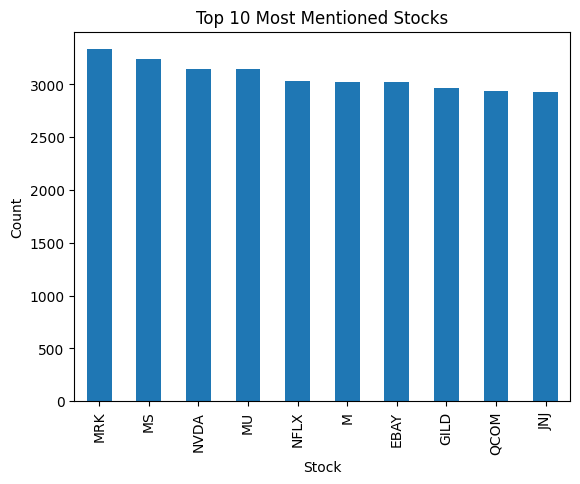

In [ ]:
import matplotlib.pyplot as plt

top_stocks = df['stock'].value_counts().head(10)

top_stocks.plot(kind='bar')

plt.title('Top 10 Most Mentioned Stocks')
plt.xlabel('Stock')
plt.ylabel('Count')

plt.show()

In [ ]:
from textblob import TextBlob

In [ ]:
df['sentiment'] = df['headline'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

df[['headline', 'sentiment']].head()

,headline,sentiment
0,Stocks That Hit 52-Week Highs On Friday,0.0
1,Stocks That Hit 52-Week Highs On Wednesday,0.0
2,71 Biggest Movers From Friday,0.0
3,46 Stocks Moving In Friday's Mid-Day Session,0.0
4,B of A Securities Maintains Neutral on Agilent...,0.0


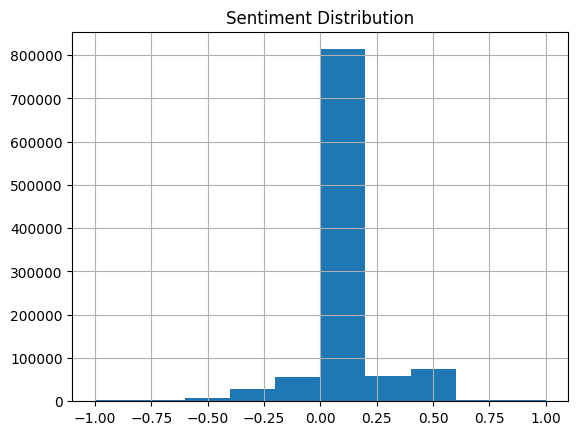

In [ ]:
df['sentiment'].hist()

plt.title('Sentiment Distribution')

plt.show()

In [ ]:
# Remove unnecessary column
df = df.drop(columns=["Unnamed: 0"])

# Check missing values
print(df.isnull().sum())

# Remove missing rows
df = df.dropna()

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Final shape
print("\nFinal Dataset Shape:")
print(df.shape)

headline           0
url                0
publisher          0
date               0
stock              0
headline_length    0
sentiment          0
dtype: int64

Duplicate rows: 1

Final Dataset Shape:
(1048574, 7)


In [ ]:
# Top publishers
top_publishers = df["publisher"].value_counts().head(10)

print(top_publishers)

publisher
Paul Quintaro        168435
Lisa Levin           139784
Benzinga Newsdesk    111281
Charles Gross         72892
Monica Gerson         61374
Eddie Staley          42702
Hal Lindon            36445
Juan Lopez            21153
Benzinga Staff        20926
ETF Professor         19812
Name: count, dtype: int64


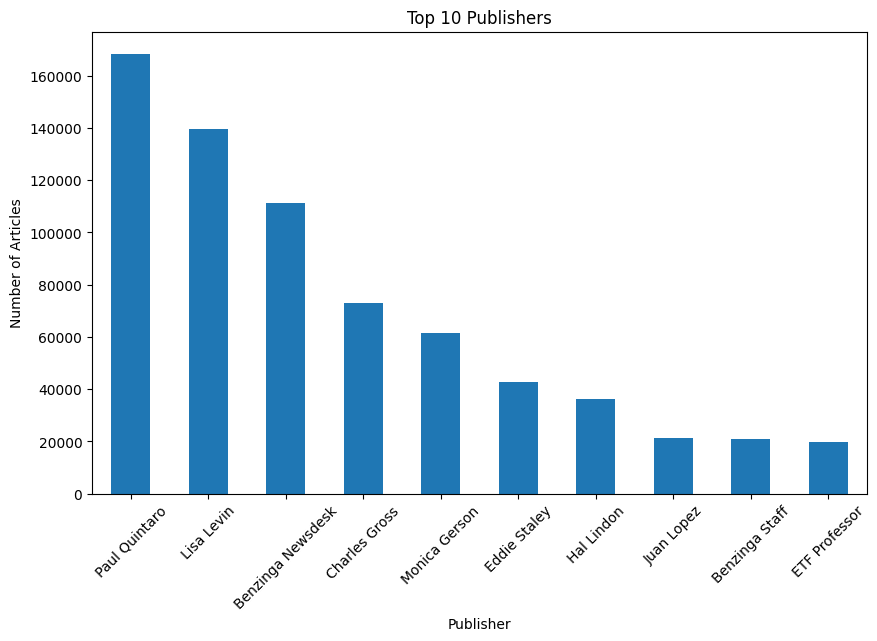

In [ ]:
plt.figure(figsize=(10,6))
top_publishers.plot(kind="bar")

plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show()

In [ ]:
top_stocks = df["stock"].value_counts().head(10)

print(top_stocks)

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
NFLX    3028
M       3025
EBAY    3018
GILD    2968
QCOM    2941
JNJ     2928
Name: count, dtype: int64


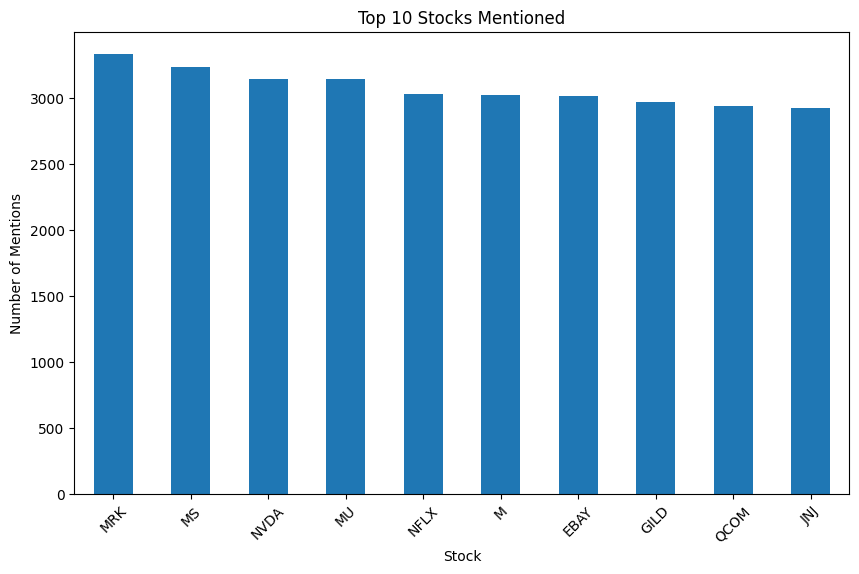

In [ ]:
plt.figure(figsize=(10,6))
top_stocks.plot(kind="bar")

plt.title("Top 10 Stocks Mentioned")
plt.xlabel("Stock")
plt.ylabel("Number of Mentions")

plt.xticks(rotation=45)

plt.show()

In [ ]:
df["headline_length"] = df["headline"].apply(len)

print(df["headline_length"].describe())

count    1.048574e+06
mean     7.300079e+01
std      4.029647e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


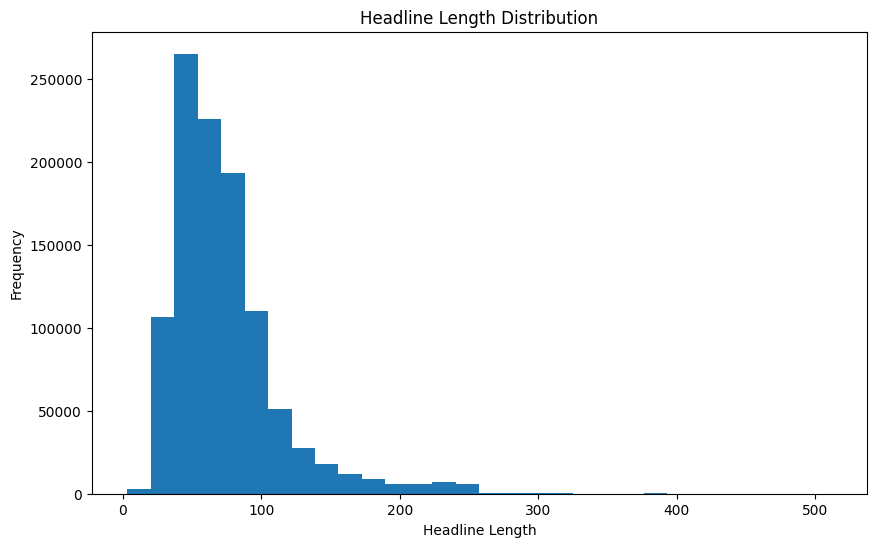

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(df["headline_length"], bins=30)

plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

## Sentiment Analysis

The sentiment analysis was performed using TextBlob polarity scores.
Positive sentiment indicates optimistic financial news headlines,
while negative sentiment indicates pessimistic news.

In [ ]:
df['headline_length'] = df['headline'].astype(str).apply(len)

print(df[['headline_length']].describe())

NameError: name 'df' is not defined

## Publisher Analysis

This section identifies the publishers contributing the most financial news headlines.

In [ ]:
top_publishers = df['publisher'].value_counts().head(10)

print(top_publishers)

NameError: name 'df' is not defined

## Stock Analysis

This analysis identifies the most frequently mentioned stock tickers in the dataset.## Stock Analysis

This analysis identifies the most frequently mentioned stock tickers in the dataset.

In [ ]:
top_stocks = df['stock'].value_counts().head(10)

print(top_stocks)

NameError: name 'df' is not defined

: 

## Technical Indicator Discussion

Technical indicators are statistical calculations used in financial market analysis.
Future work will include:

- Moving Average (MA)
- Relative Strength Index (RSI)
- MACD
- Stock price trend analysis

## Technical Indicators

Technical indicators help analyze stock market trends and price movement behavior.
This section demonstrates simple moving average calculations using sample stock prices.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample stock price data
stock_prices = [100, 102, 101, 105, 107, 110, 108, 111, 115, 117]

stock_df = pd.DataFrame({
    'Price': stock_prices
})

# Calculate Moving Average
stock_df['Moving_Average_3'] = stock_df['Price'].rolling(window=3).mean()

print(stock_df)

In [ ]:
stock_df.plot(figsize=(8,5))
plt.title("Stock Price and Moving Average")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

: 

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

## NLP and Market Trend Relationship

Natural Language Processing (NLP) techniques can help determine whether financial news sentiment influences stock market behavior.

Positive news sentiment may correlate with upward market movement, while negative sentiment may correlate with declining stock prices.

Future work will combine sentiment scores with historical stock price datasets for deeper market prediction analysis.